In [6]:
import numpy as np
from scipy.constants import c, pi
from scipy.special import spherical_jn, spherical_yn

def rcs_sphere_approx(radius, frequency):
    """
    RCS einer Kugel mit Näherungsformeln:
    - Rayleigh-Bereich (ka << 1)
    - Resonanzbereich: kein einfaches Modell -> NaN
    - Optischer Bereich (ka >> 1)
    """
    wavelength = c / frequency
    k = 2 * pi / wavelength
    ka = k * radius

    if ka < 0.1:
        # Rayleigh approximation
        sigma = (9 * pi * radius**6) / (wavelength**4)
    elif ka > 10:
        # Optical region (geometric optics approximation)
        sigma = pi * radius**2
    else:
        # No simple approximation valid
        sigma = np.nan

    return sigma


def rcs_sphere_exact(radius, frequency, n_terms=100):
    """
    Exakte RCS einer Kugel über Mie-Reihe mit den ersten n_terms.
    """
    wavelength = c / frequency
    k = 2 * pi / wavelength
    x = k * radius

    # Besselfunktionen
    jn = lambda n, x: spherical_jn(n, x)
    yn = lambda n, x: spherical_yn(n, x)
    h1n = lambda n, x: jn(n, x) + 1j * yn(n, x)

    # Koeffizienten (Mie-Koeffizienten für perfekt leitende Kugel)
    a_n = []
    for n in range(1, n_terms + 1):
        num = jn(n, x)
        den = h1n(n, x)
        a = (num / den)
        a_n.append(a)

    # Summe über n
    S1 = sum((2 * n + 1) * (-1)**n * a for n, a in enumerate(a_n, start=1))
    sigma = (wavelength**2 / pi) * abs(S1)**2
    return sigma


def rcs_corner_reflector(sidelength, frequency):
    """
    RCS eines Eckreflektors mit der Näherungsformel:
    σ = (12 * π * a^4) / λ^2
    Gültig für große Reflektoren (a >> λ)
    """
    wavelength = c / frequency
    if sidelength < wavelength / 10:
        sigma = np.nan  # nicht gültig
    else:
        sigma = (12 * pi * sidelength**4) / (wavelength**2)

    return sigma


RCS Kugel (Approx): 0.007853981633974483
RCS Kugel (Exakt): 0.006756048401469882
RCS Corner (Approx): 4.194591890537184


In [7]:
###### Test the functions ######
f = 10e9  # 10 GHz
r = 0.05  # 5 cm Kugelradius

print("RCS Kugel (Approx):", rcs_sphere_approx(r, f))
print("RCS Kugel (Exakt):", rcs_sphere_exact(r, f))
print("RCS Corner (Approx):", rcs_corner_reflector(0.1, f))


RCS Kugel (Approx): 0.007853981633974483
RCS Kugel (Exakt): 0.006756048401469882
RCS Corner (Approx): 4.194591890537184


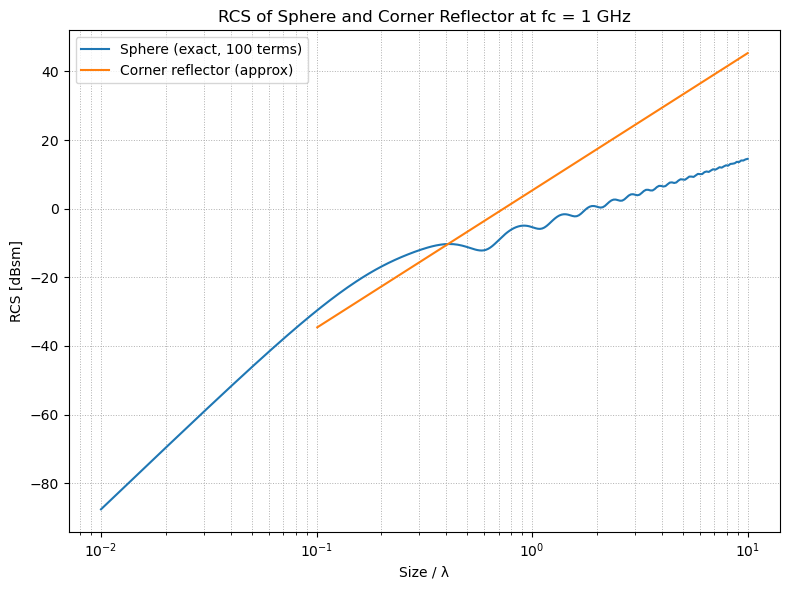

C:\Users\stec\AppData\Local\Temp\ipykernel_7880\1208809209.py:47: RuntimeWarning: invalid value encountered in scalar divide
  a = (num / den)


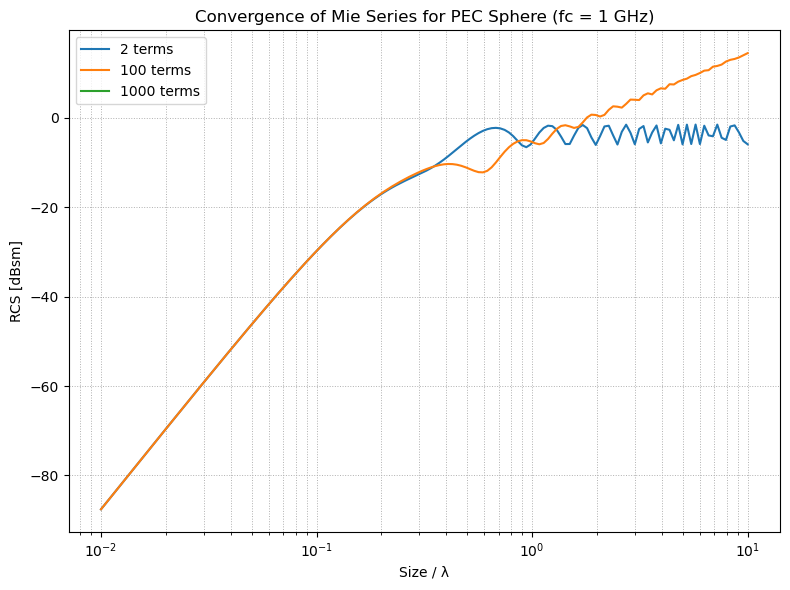

In [8]:
fc = 1e9              # Frequenz in Hz
wavelength = c / fc   # Wellenlänge
sizes = np.logspace(np.log10(0.01 * wavelength), np.log10(10 * wavelength), 300)

# Berechnungen
sigma_sphere = np.array([rcs_sphere_exact(r, fc, n_terms=100) for r in sizes])
sigma_corner = np.array([rcs_corner_reflector(a, fc) for a in sizes])

# In dBsm umrechnen
def to_dB(x):
    with np.errstate(divide='ignore', invalid='ignore'):
        return 10 * np.log10(x)

sigma_sphere_dB = to_dB(sigma_sphere)
sigma_corner_dB = to_dB(sigma_corner)

# Plot
plt.figure(figsize=(8,6))
plt.semilogx(sizes / wavelength, sigma_sphere_dB, label="Sphere (exact, 100 terms)")
plt.semilogx(sizes / wavelength, sigma_corner_dB, label="Corner reflector (approx)")
plt.xlabel("Size / λ")
plt.ylabel("RCS [dBsm]")
plt.title("RCS of Sphere and Corner Reflector at fc = 1 GHz")
plt.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. Konvergenz-Plot: Einfluss der Anzahl der Mie-Terme
# ------------------------------------------------------------

sizes_conv = np.logspace(np.log10(0.01 * wavelength), np.log10(10 * wavelength), 150)
sigma_n2 = np.array([rcs_sphere_exact(r, fc, n_terms=2) for r in sizes_conv])
sigma_n100 = np.array([rcs_sphere_exact(r, fc, n_terms=100) for r in sizes_conv])
sigma_n1000 = np.array([rcs_sphere_exact(r, fc, n_terms=1000) for r in sizes_conv])

plt.figure(figsize=(8,6))
plt.semilogx(sizes_conv / wavelength, to_dB(sigma_n2), label="2 terms")
plt.semilogx(sizes_conv / wavelength, to_dB(sigma_n100), label="100 terms")
plt.semilogx(sizes_conv / wavelength, to_dB(sigma_n1000), label="1000 terms")
plt.xlabel("Size / λ")
plt.ylabel("RCS [dBsm]")
plt.title("Convergence of Mie Series for PEC Sphere (fc = 1 GHz)")
plt.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.legend()
plt.tight_layout()
plt.show()